# HEBCS Clinical Risk Prediction — 11 Dialysis Complication Classifiers

**Patient**: Patient-001 | **Dx**: ESRD on Home Hemodialysis (Non-Diabetic)

Uses HEBCS pathway scores + raw clinical data to predict:

| # | Target | Type | Data Source | Threshold |
|---|--------|------|-------------|-----------|
| 1 | **Inter-dialysis Hypotension** | Binary | BP readings | SBP < 90 mmHg |
| 2 | **Bloody Bowel Movement** | Binary | Elimination log | blood=True/TRACE |
| 3 | **Intra-dialysis Vomiting** | Binary | Vomit log | Within 6 hrs of Tx |
| 4 | **Post-dialysis Vomiting** | Binary | Vomit log | > 6 hrs after Tx |
| 5 | **Ongoing Hemolysis** | Binary | Labs | LDH > 250 |
| 6 | **Low Hemoglobin** | Binary | Labs | Hgb < 10 g/dL |
| 7 | **Hypokalemia** | Binary | Labs | K < 3.5 mEq/L |
| 8 | **Low Calcium** | Binary | Labs | Ca < 8.5 mg/dL |
| 9 | **Ongoing Calcification** | Binary | Labs | CaxP > 55 |
| 10 | **Abnormal Blood Glucose** | Regression | Labs | Predict level |
| 11 | **High PTH** | Binary | Labs | PTH > 300 pg/mL |

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, confusion_matrix, f1_score,
                             average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
import shap

# Viz
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=1.1)

# Paths
from pathlib import Path
ML_ROOT = Path('..') if Path('../data').exists() else Path('.')
DATA_PROC = ML_ROOT / 'data' / 'processed'
DATA_FEAT = ML_ROOT / 'data' / 'features'
MODEL_DIR = ML_ROOT / 'models'
MODEL_DIR.mkdir(exist_ok=True)

print("Libraries loaded ✅")

Libraries loaded ✅


## 2. Load and Explore the Dialysis Patient Dataset

In [2]:
# ── Load all data sources ──
sessions = pd.read_csv(DATA_PROC / 'dialysis_sessions.csv', low_memory=False)
sessions['session_date'] = pd.to_datetime(sessions['session_date'])

readings = pd.read_csv(DATA_PROC / 'dialysis_readings.csv')
readings['session_date'] = pd.to_datetime(readings['session_date'])

labs = pd.read_csv(DATA_FEAT / 'lab_pivot_canonical.csv')
labs['date'] = pd.to_datetime(labs['date'])

elim = pd.read_csv(DATA_PROC / 'unified_elimination.csv')
elim['date'] = pd.to_datetime(elim['date'])

# Derive vomit subset from unified_elimination (vomit merged in NB01)
if 'type' in elim.columns:
    vomit = elim[elim['type'] == 'vomit'].copy()
else:
    vomit = pd.DataFrame(columns=elim.columns)
    vomit['date'] = pd.to_datetime(vomit['date'])

pathway_scores = pd.read_csv(DATA_FEAT / 'HEBCS_pathway_scores.csv')
pathway_scores['date'] = pd.to_datetime(pathway_scores['date'])

wellness = pd.read_csv(DATA_FEAT / 'HEBCS_wellness_daily.csv')
wellness.rename(columns={wellness.columns[0]: 'date'}, inplace=True)
wellness['date'] = pd.to_datetime(wellness['date'])

# ── NEW: Nutrition data ──
nutrition = pd.read_csv(DATA_PROC / 'unified_nutrition.csv')
nutrition['date'] = pd.to_datetime(nutrition['date'])
nutr_agg_cols = ['calories', 'protein', 'carbs', 'fat', 'fiber',
                 'sodium', 'potassium', 'calcium', 'phosphorus', 'iron',
                 'sugar', 'cholesterol']
for c in nutr_agg_cols:
    if c in nutrition.columns:
        nutrition[c] = pd.to_numeric(nutrition[c], errors='coerce')
# Aggregate to daily totals
daily_nutrition = (nutrition.groupby(nutrition['date'].dt.normalize())
                   [nutr_agg_cols].sum().replace(0, np.nan))
daily_nutrition.columns = ['nutr_' + c for c in daily_nutrition.columns]

# ── NEW: Medications data ──
medications = pd.read_csv(DATA_PROC / 'medications.csv')
medications['date'] = pd.to_datetime(medications['date'])
# One-hot encode daily medication flags
med_dummies = pd.get_dummies(medications['medication_name'], prefix='med')
med_dummies['date'] = medications['date'].dt.normalize()
daily_meds = med_dummies.groupby('date').max()  # binary: took it or not
# Also count total meds per day
daily_meds['med_count'] = medications.groupby(medications['date'].dt.normalize()).size()

print(f"Sessions:        {sessions.shape}")
print(f"Readings:        {readings.shape}")
print(f"Labs:            {labs.shape}")
print(f"Elimination:     {elim.shape}  (bowel: {(elim['type']=='bowel').sum() if 'type' in elim.columns else len(elim)}, vomit: {len(vomit)})")
print(f"Pathway scores:  {pathway_scores.shape}")
print(f"Wellness:        {wellness.shape}")
print(f"Nutrition:       {nutrition.shape}  → Daily: {daily_nutrition.shape}")
print(f"Medications:     {medications.shape}  → Daily: {daily_meds.shape}")
print(f"\nDate ranges:")
print(f"  Sessions:    {sessions.session_date.min().date()} → {sessions.session_date.max().date()}")
print(f"  Labs:        {labs.date.min().date()} → {labs.date.max().date()}")
print(f"  Nutrition:   {daily_nutrition.index.min().date()} → {daily_nutrition.index.max().date()}")
print(f"  Medications: {daily_meds.index.min().date()} → {daily_meds.index.max().date()}")
if not vomit.empty:
    print(f"  Vomit:       {vomit.date.min().date()} → {vomit.date.max().date()}")
print(f"\nTop medications: {list(daily_meds.columns[:8])}")
print(f"Nutrition fill rate: {daily_nutrition.notna().mean().mean()*100:.1f}%")

Sessions:        (1797, 105)
Readings:        (15711, 14)
Labs:            (308, 52)
Elimination:     (3844, 17)  (bowel: 2469, vomit: 1375)
Pathway scores:  (2156, 6)
Wellness:        (3585, 14)
Nutrition:       (4094, 33)  → Daily: (1846, 12)
Medications:     (953, 13)  → Daily: (257, 12)

Date ranges:
  Sessions:    2016-04-28 → 2026-02-17
  Labs:        2016-04-28 → 2026-02-09
  Nutrition:   2016-06-14 → 2026-02-19
  Medications: 2025-06-01 → 2026-02-20
  Vomit:       2021-01-02 → 2026-02-17

Top medications: ['med_Calcitriol', 'med_Calcium Carbonate', 'med_Cetirizine Hydrochloride', 'med_Cyclobenzeprine', 'med_Docusolate', 'med_Folic Acid', 'med_Marine Bone Discovery', 'med_Oedesetron']
Nutrition fill rate: 5.3%


## 3. Define Clinical Targets and Build Session-Level Feature Matrix

We build a **per-session** feature matrix where each row is a dialysis session date. For each session we:
- Compute whether intra-dialysis hypotension occurred (any reading SBP < 90)
- Check for bloody bowel movement the same day or next day
- Classify vomiting as intra-dialysis (≤6h after Tx start) or post-dialysis (>6h)
- Forward-fill labs to get the most recent lab values at each session
- Attach HEBCS pathway scores as features

In [3]:
# ══════════════════════════════════════════════════════════
# 3a. TARGET 1 — Intra-dialysis Hypotension (SBP < 90)
# ══════════════════════════════════════════════════════════
readings['bp_sys'] = pd.to_numeric(readings['bp_sys'], errors='coerce')
hypo_by_session = (readings.groupby('session_date')['bp_sys']
                   .agg(min_bp='min', mean_bp='mean', max_bp='max',
                        n_readings='count',
                        hypo_count=lambda x: (x < 90).sum()))
hypo_by_session['hypotension'] = (hypo_by_session['hypo_count'] > 0).astype(int)
print(f"TARGET 1 — Hypotension events: {hypo_by_session['hypotension'].sum()} / {len(hypo_by_session)} sessions "
      f"({100*hypo_by_session['hypotension'].mean():.1f}%)")

# ══════════════════════════════════════════════════════════
# 3b. TARGET 2 — Bloody Bowel Movement (same-day or next-day)
# ══════════════════════════════════════════════════════════
elim['bloody'] = elim['blood'].isin(['True', 'TRACE', 'ÝES']).astype(int)
bloody_daily = elim.groupby('date')['bloody'].max().reset_index()
bloody_daily.columns = ['date', 'bloody_bm']
print(f"TARGET 2 — Bloody BM days: {bloody_daily['bloody_bm'].sum()} / {len(bloody_daily)}")

# ══════════════════════════════════════════════════════════
# 3c. TARGETS 3 & 4 — Intra-dialysis vs Post-dialysis Vomiting
# ══════════════════════════════════════════════════════════
# Without precise treatment timestamps on most vomit records,
# we classify: same-day vomit = intra-dialysis; vomit on non-session day = post-dialysis
session_dates_set = set(sessions['session_date'].dt.date)
vomit_daily = vomit.groupby('date').size().reset_index(name='vomit_count')
vomit_daily['is_session_day'] = vomit_daily['date'].dt.date.isin(session_dates_set)
vomit_daily['intra_dialysis_vomit'] = (vomit_daily['is_session_day'] & (vomit_daily['vomit_count'] > 0)).astype(int)

# Post-dialysis: vomit on non-session day (inter-dialysis period)
vomit_daily['post_dialysis_vomit'] = (~vomit_daily['is_session_day'] & (vomit_daily['vomit_count'] > 0)).astype(int)
print(f"TARGET 3 — Intra-dialysis vomit days: {vomit_daily['intra_dialysis_vomit'].sum()}")
print(f"TARGET 4 — Post-dialysis vomit days: {vomit_daily['post_dialysis_vomit'].sum()}")

# ══════════════════════════════════════════════════════════
# 3d. TARGETS 5-11 — Lab-based binary targets
# ══════════════════════════════════════════════════════════
lab_targets = pd.DataFrame({'date': labs['date']})
for col in labs.columns[1:]:
    labs[col] = pd.to_numeric(labs[col], errors='coerce')

lab_targets['hemolysis']        = (labs['LDH'] > 250).astype(float)  # TARGET 5
lab_targets['low_hemoglobin']   = (labs['Hemoglobin'] < 10).astype(float)  # TARGET 6
lab_targets['hypokalemia']      = (labs['Potassium'] < 3.5).astype(float)  # TARGET 7
lab_targets['low_calcium']      = (labs['Calcium'] < 8.5).astype(float)  # TARGET 8
lab_targets['calcification']    = ((labs['CaxP'] > 55) | (labs['Phosphorus'] > 6.5)).astype(float)  # TARGET 9
lab_targets['glucose_level']    = labs['Glucose'].copy()  # TARGET 10 (regression)
lab_targets['high_pth']         = (labs['PTH'] > 300).astype(float)  # TARGET 11

for t in ['hemolysis','low_hemoglobin','hypokalemia','low_calcium','calcification','high_pth']:
    n_pos = lab_targets[t].sum()
    n_tot = lab_targets[t].notna().sum()
    print(f"TARGET — {t}: {n_pos:.0f} / {n_tot} ({100*n_pos/max(n_tot,1):.1f}%)")

TARGET 1 — Hypotension events: 817 / 1594 sessions (51.3%)
TARGET 2 — Bloody BM days: 355 / 1655
TARGET 3 — Intra-dialysis vomit days: 582
TARGET 4 — Post-dialysis vomit days: 438
TARGET — hemolysis: 25 / 308 (8.1%)
TARGET — low_hemoglobin: 133 / 308 (43.2%)
TARGET — hypokalemia: 23 / 308 (7.5%)
TARGET — low_calcium: 15 / 308 (4.9%)
TARGET — calcification: 86 / 308 (27.9%)
TARGET — high_pth: 159 / 308 (51.6%)


In [4]:
# ══════════════════════════════════════════════════════════
# 3e. Build Session-Level Feature Matrix
# ══════════════════════════════════════════════════════════

# ── Session vitals ──
num_cols = ['today_weight_kg', 'post_weight_kg', 'weight_loss_kg',
            'pre_bp_sys', 'pre_bp_dia', 'post_bp_sys', 'post_bp_dia',
            'pre_pulse', 'post_pulse', 'avg_blood_flow_rate',
            'ktv_actual', 'urr', 'npcr', 'weight_gain_bt']
for c in num_cols:
    if c in sessions.columns:
        sessions[c] = pd.to_numeric(sessions[c], errors='coerce')

sess_features = sessions[['session_date'] + [c for c in num_cols if c in sessions.columns]].copy()
sess_features = sess_features.set_index('session_date').sort_index()

# ══════════════════════════════════════════════════════════
# 3f. DIALYSIS PARAMETERS — duration, dialysate, fluid, BVP
# ══════════════════════════════════════════════════════════
dialysis_param_cols = {
    'total_time':              'dial_duration_min',
    'dialysate_volume_L':      'dial_dialysate_vol_L',
    'total_dialysate_L':       'dial_total_dialysate_L',
    'total_bvp':               'dial_bvp_L',
    'total_uf_kg':             'dial_fluid_removed_kg',
    'avg_blood_flow_rate':     'dial_avg_bfr',
    'dialysate_lactate':       'dial_lactate',
    'dialysate_k':             'dial_K_bath',
    'bath_ca':                 'dial_Ca_bath',
    'bath_k':                  'dial_K_bath2',
    'bath_na':                 'dial_Na_bath',
    'conductivity':            'dial_conductivity',
    'manual_ph':               'dial_ph',
    'ktv_actual':              'dial_ktv',
    'urr':                     'dial_urr',
    'npcr':                    'dial_npcr',
    'weight_loss_kg':          'dial_wt_loss_kg',
    'weight_gain_bt':          'dial_wt_gain_bt',
    'pre_pulse':               'dial_pre_hr',
    'post_pulse':              'dial_post_hr',
    'pre_temp':                'dial_pre_temp',
    'post_temp':               'dial_post_temp',
}
sess_indexed = sessions.set_index('session_date')
for src, dst in dialysis_param_cols.items():
    if src in sessions.columns and dst not in sess_features.columns:
        sess_features[dst] = pd.to_numeric(sess_indexed[src], errors='coerce').reindex(sess_features.index)

# Derived dialysis features
if 'dial_post_hr' in sess_features.columns and 'dial_pre_hr' in sess_features.columns:
    sess_features['dial_hr_delta'] = sess_features['dial_post_hr'] - sess_features['dial_pre_hr']
if 'dial_post_temp' in sess_features.columns and 'dial_pre_temp' in sess_features.columns:
    sess_features['dial_temp_delta'] = sess_features['dial_post_temp'] - sess_features['dial_pre_temp']
if 'pre_bp_sys' in sess_features.columns and 'post_bp_sys' in sess_features.columns:
    sess_features['dial_bp_drop'] = sess_features['pre_bp_sys'] - sess_features['post_bp_sys']
if 'dial_duration_min' in sess_features.columns and 'dial_fluid_removed_kg' in sess_features.columns:
    dur = sess_features['dial_duration_min']
    uf  = sess_features['dial_fluid_removed_kg']
    sess_features['dial_uf_rate_kg_hr'] = np.where(dur > 0, uf / (dur / 60), np.nan)

print(f"  ✓ Dialysis parameters added: {sum(1 for c in sess_features.columns if c.startswith('dial_'))} features")

# ══════════════════════════════════════════════════════════
# 3g. INTRA-DIALYSIS READINGS — BP/HR variability per session
# ══════════════════════════════════════════════════════════
for col in ['bp_sys', 'bp_dia', 'pulse', 'blood_flow_rate',
            'uf_rate', 'arterial_pressure', 'venous_pressure']:
    readings[col] = pd.to_numeric(readings[col], errors='coerce')

rdg_agg = readings.groupby('session_date').agg(
    rdg_bp_sys_min   = ('bp_sys', 'min'),
    rdg_bp_sys_max   = ('bp_sys', 'max'),
    rdg_bp_sys_mean  = ('bp_sys', 'mean'),
    rdg_bp_sys_std   = ('bp_sys', 'std'),
    rdg_bp_dia_mean  = ('bp_dia', 'mean'),
    rdg_bp_dia_std   = ('bp_dia', 'std'),
    rdg_pulse_mean   = ('pulse', 'mean'),
    rdg_pulse_std    = ('pulse', 'std'),
    rdg_pulse_max    = ('pulse', 'max'),
    rdg_bfr_mean     = ('blood_flow_rate', 'mean'),
    rdg_uf_rate_mean = ('uf_rate', 'mean'),
    rdg_uf_rate_max  = ('uf_rate', 'max'),
    rdg_art_press_mean = ('arterial_pressure', 'mean'),
    rdg_ven_press_mean = ('venous_pressure', 'mean'),
    rdg_n_readings   = ('bp_sys', 'count'),
)
rdg_agg['rdg_bp_sys_range'] = rdg_agg['rdg_bp_sys_max'] - rdg_agg['rdg_bp_sys_min']
rdg_agg['rdg_map_mean'] = rdg_agg['rdg_bp_dia_mean'] + (rdg_agg['rdg_bp_sys_mean'] - rdg_agg['rdg_bp_dia_mean']) / 3

print(f"  ✓ Reading aggregates added: {rdg_agg.shape[1]} features from {len(rdg_agg)} sessions")

# ══════════════════════════════════════════════════════════
# 3h. NUTRITION — same-day & day-before intake
# ══════════════════════════════════════════════════════════
nutr_same = daily_nutrition.reindex(sess_features.index)
nutr_same.columns = [c + '_today' for c in nutr_same.columns]

nutr_prev = daily_nutrition.reindex(sess_features.index - pd.Timedelta(days=1))
nutr_prev.index = sess_features.index
nutr_prev.columns = [c.replace('nutr_', 'nutr_prev_') for c in daily_nutrition.columns]

nutr_3d = daily_nutrition.rolling(3, min_periods=1).mean()
nutr_3d_at_sess = nutr_3d.reindex(sess_features.index)
nutr_3d_at_sess.columns = [c + '_3d_avg' for c in daily_nutrition.columns]

nutr_coverage = nutr_same.notna().any(axis=1).sum()
print(f"  ✓ Nutrition features: {nutr_same.shape[1]+nutr_prev.shape[1]+nutr_3d_at_sess.shape[1]} cols, "
      f"sessions with same-day data: {nutr_coverage} / {len(sess_features)}")

# ══════════════════════════════════════════════════════════
# 3i. MEDICATIONS — binary flags per med + count
# ══════════════════════════════════════════════════════════
meds_at_session = daily_meds.reindex(sess_features.index).fillna(0).astype(int)
binder_cols = [c for c in meds_at_session.columns if 'Carbonate' in c]
if binder_cols:
    meds_at_session['med_any_binder'] = meds_at_session[binder_cols].max(axis=1)
calcitriol_cols = [c for c in meds_at_session.columns if 'Calcitriol' in c]
if calcitriol_cols:
    meds_at_session['med_calcitriol'] = meds_at_session[calcitriol_cols].max(axis=1)

print(f"  ✓ Medication features: {meds_at_session.shape[1]} cols, "
      f"sessions with any med: {(meds_at_session.get('med_count', pd.Series(0)) > 0).sum()}")

# ══════════════════════════════════════════════════════════
# 3j. LABS, PATHWAYS, WELLNESS
# ══════════════════════════════════════════════════════════
lab_key_cols = ['Hemoglobin', 'Hematocrit', 'Potassium', 'Calcium', 'Phosphorus',
                'PTH', 'LDH', 'Glucose', 'BUN', 'Creatinine', 'Albumin',
                'Iron', 'Ferritin', 'ISAT', 'CaxP', 'KtV', 'URR', 'nPCR',
                'Sodium', 'CO2', 'WBC', 'RBC', 'RDW', 'MCV', 'Reticulocyte']
lab_sub = labs.set_index('date')[lab_key_cols].sort_index()
all_dates = sess_features.index.union(lab_sub.index).sort_values()
lab_ffill = lab_sub.reindex(all_dates).ffill()
lab_at_session = lab_ffill.reindex(sess_features.index)
lab_at_session.columns = ['lab_' + c for c in lab_at_session.columns]

bp_stats = hypo_by_session[['min_bp', 'mean_bp', 'max_bp', 'n_readings']]

pw_pivot = pathway_scores.pivot_table(index='date', columns='pathway', values='score')
pw_pivot = pw_pivot.reindex(all_dates).ffill()
pw_at_session = pw_pivot.reindex(sess_features.index)
pw_at_session.columns = ['pw_' + c for c in pw_at_session.columns]

well_sub = wellness.set_index('date')[['W_product', 'W_additive']].sort_index()
well_ffill = well_sub.reindex(all_dates).ffill()
well_at_session = well_ffill.reindex(sess_features.index)

# ══════════════════════════════════════════════════════════
# 3k. MERGE TARGETS & FINAL ASSEMBLY
# ══════════════════════════════════════════════════════════
bloody_lookup = bloody_daily.set_index('date')['bloody_bm']
sess_features['bloody_bm_today'] = sess_features.index.map(
    lambda d: int(bloody_lookup.get(d, 0)))
sess_features['bloody_bm_prev'] = sess_features.index.map(
    lambda d: int(bloody_lookup.get(d - pd.Timedelta(days=1), 0)))

vomit_lookup = vomit_daily.set_index('date')
sess_features['vomit_today'] = sess_features.index.map(
    lambda d: vomit_lookup['vomit_count'].get(d, 0))
sess_features['vomit_yesterday'] = sess_features.index.map(
    lambda d: vomit_lookup['vomit_count'].get(d - pd.Timedelta(days=1), 0))

sess_features['day_of_week'] = sess_features.index.dayofweek
sess_features['month'] = sess_features.index.month
sess_features['days_since_start'] = (sess_features.index - sess_features.index.min()).days

for c in ['pre_bp_sys', 'pre_bp_dia', 'pre_pulse', 'weight_loss_kg']:
    if c in sess_features.columns:
        sess_features[f'{c}_lag1'] = sess_features[c].shift(1)

# ── COMBINE EVERYTHING ──
feature_matrix = pd.concat([
    sess_features, rdg_agg, lab_at_session, bp_stats,
    pw_at_session, well_at_session,
    nutr_same, nutr_prev, nutr_3d_at_sess,
    meds_at_session,
], axis=1)

# ── Attach targets ──
feature_matrix['hypotension'] = hypo_by_session['hypotension']
for t in ['hemolysis','low_hemoglobin','hypokalemia','low_calcium','calcification','glucose_level','high_pth']:
    lt = lab_targets.set_index('date')[[t]]
    lt_ffill = lt.reindex(all_dates).ffill()
    feature_matrix[t] = lt_ffill.reindex(feature_matrix.index)[t]

vomit_intra = vomit_daily.set_index('date')['intra_dialysis_vomit']
vomit_post = vomit_daily.set_index('date')['post_dialysis_vomit']
feature_matrix['intra_vomit_target'] = feature_matrix.index.map(lambda d: int(vomit_intra.get(d, 0)))
feature_matrix['post_vomit_target'] = feature_matrix.index.map(lambda d: int(vomit_post.get(d + pd.Timedelta(days=1), 0)))

bm_today = feature_matrix['bloody_bm_today'].fillna(0).astype(int)
bm_next  = feature_matrix.index.map(lambda d: int(bloody_lookup.get(d + pd.Timedelta(days=1), 0)))
feature_matrix['bloody_bm_target'] = (bm_today | bm_next).astype(int)

print(f"\n{'='*70}")
print(f"FULL FEATURE MATRIX: {feature_matrix.shape}")
print(f"  Session vitals & dialysis params: {sum(1 for c in feature_matrix.columns if c.startswith('dial_'))}")
print(f"  Intra-dialysis readings:          {sum(1 for c in feature_matrix.columns if c.startswith('rdg_'))}")
print(f"  Lab values:                       {sum(1 for c in feature_matrix.columns if c.startswith('lab_'))}")
print(f"  HEBCS pathway scores:             {sum(1 for c in feature_matrix.columns if c.startswith('pw_'))}")
print(f"  Nutrition features:               {sum(1 for c in feature_matrix.columns if 'nutr' in c)}")
print(f"  Medication features:              {sum(1 for c in feature_matrix.columns if c.startswith('med_'))}")
print(f"  Temporal + lag + other:            {feature_matrix.shape[1] - sum(1 for c in feature_matrix.columns if any(c.startswith(p) for p in ['dial_','rdg_','lab_','pw_','nutr','med_']))}")
print(f"  Date range: {feature_matrix.index.min().date()} → {feature_matrix.index.max().date()}")
print(f"{'='*70}")

targets_list = ['hypotension', 'bloody_bm_target', 'intra_vomit_target', 'post_vomit_target',
                'hemolysis', 'low_hemoglobin', 'hypokalemia', 'low_calcium',
                'calcification', 'glucose_level', 'high_pth']
print("\n── Target Distributions ──")
for t in targets_list:
    if t == 'glucose_level':
        v = feature_matrix[t].dropna()
        print(f"  {t}: N={len(v)}, mean={v.mean():.1f}, std={v.std():.1f}")
    else:
        v = feature_matrix[t].dropna()
        print(f"  {t}: {v.sum():.0f} / {len(v)} ({100*v.mean():.1f}%)")

  ✓ Dialysis parameters added: 26 features
  ✓ Reading aggregates added: 17 features from 1594 sessions
  ✓ Nutrition features: 36 cols, sessions with same-day data: 40 / 1797
  ✓ Medication features: 14 cols, sessions with any med: 98

FULL FEATURE MATRIX: (1798, 167)
  Session vitals & dialysis params: 26
  Intra-dialysis readings:          17
  Lab values:                       25
  HEBCS pathway scores:             7
  Nutrition features:               36
  Medication features:              14
  Temporal + lag + other:            42
  Date range: 2013-05-21 → 2026-02-17

── Target Distributions ──
  hypotension: 817 / 1594 (51.3%)
  bloody_bm_target: 191 / 1798 (10.6%)
  intra_vomit_target: 582 / 1798 (32.4%)
  post_vomit_target: 374 / 1798 (20.8%)
  hemolysis: 196 / 1797 (10.9%)
  low_hemoglobin: 770 / 1797 (42.8%)
  hypokalemia: 178 / 1797 (9.9%)
  low_calcium: 104 / 1797 (5.8%)
  calcification: 726 / 1797 (40.4%)
  glucose_level: N=1788, mean=145.7, std=50.6
  high_pth: 1337 / 1

## 4. Handle Missing Values and Preprocessing

In [5]:
# ── Identify feature columns (exclude targets) ──
target_cols = ['hypotension', 'bloody_bm_target', 'intra_vomit_target', 'post_vomit_target',
               'hemolysis', 'low_hemoglobin', 'hypokalemia', 'low_calcium',
               'calcification', 'glucose_level', 'high_pth']
feature_cols = [c for c in feature_matrix.columns if c not in target_cols]

# ── Missing value analysis ──
missing = feature_matrix[feature_cols].isnull().sum()
missing_pct = 100 * missing / len(feature_matrix)
missing_df = pd.DataFrame({'missing': missing, 'pct': missing_pct}).query('pct > 0').sort_values('pct', ascending=False)
print(f"Features with missing values: {len(missing_df)} / {len(feature_cols)}")
print(f"\nTop 20 most missing:")
print(missing_df.head(20).to_string())

# ── Drop features with >85% missing ──
drop_cols = missing_df[missing_df.pct > 85].index.tolist()
if drop_cols:
    print(f"\nDropping {len(drop_cols)} features with >85% missing: {drop_cols[:10]}{'...' if len(drop_cols) > 10 else ''}")
    feature_cols = [c for c in feature_cols if c not in drop_cols]

# ── Categorize features ──
dial_feats = [c for c in feature_cols if c.startswith('dial_')]
rdg_feats  = [c for c in feature_cols if c.startswith('rdg_')]
lab_feats  = [c for c in feature_cols if c.startswith('lab_')]
pw_feats   = [c for c in feature_cols if c.startswith('pw_')]
nutr_feats = [c for c in feature_cols if 'nutr' in c]
med_feats  = [c for c in feature_cols if c.startswith('med_')]
other_feats = [c for c in feature_cols if not any(c.startswith(p) for p in ['dial_','rdg_','lab_','pw_','med_']) and 'nutr' not in c]

print(f"\nFinal features: {len(feature_cols)}")
print(f"  Dialysis parameters: {len(dial_feats)}")
print(f"  Intra-dialysis readings: {len(rdg_feats)}")
print(f"  Lab values: {len(lab_feats)}")
print(f"  HEBCS pathways: {len(pw_feats)}")
print(f"  Nutrition: {len(nutr_feats)}")
print(f"  Medications: {len(med_feats)}")
print(f"  Other (vitals, temporal, lag): {len(other_feats)}")

Features with missing values: 156 / 156

Top 20 most missing:
                        missing         pct
dial_uf_rate_kg_hr         1798  100.000000
dial_npcr                  1793   99.721913
npcr                       1793   99.721913
dial_urr                   1784   99.221357
urr                        1784   99.221357
dial_ktv                   1777   98.832036
ktv_actual                 1777   98.832036
dial_conductivity          1774   98.665184
dial_ph                    1773   98.609566
dial_K_bath2               1762   97.997775
dial_Na_bath               1762   97.997775
dial_Ca_bath               1762   97.997775
nutr_cholesterol_today     1760   97.886541
nutr_potassium_today       1758   97.775306
nutr_fat_today             1758   97.775306
nutr_phosphorus_today      1758   97.775306
nutr_carbs_today           1758   97.775306
nutr_sodium_today          1758   97.775306
nutr_calories_today        1758   97.775306
nutr_iron_today            1758   97.775306

Dropping 51 f

## 5. Exploratory Data Analysis of Risk Factors

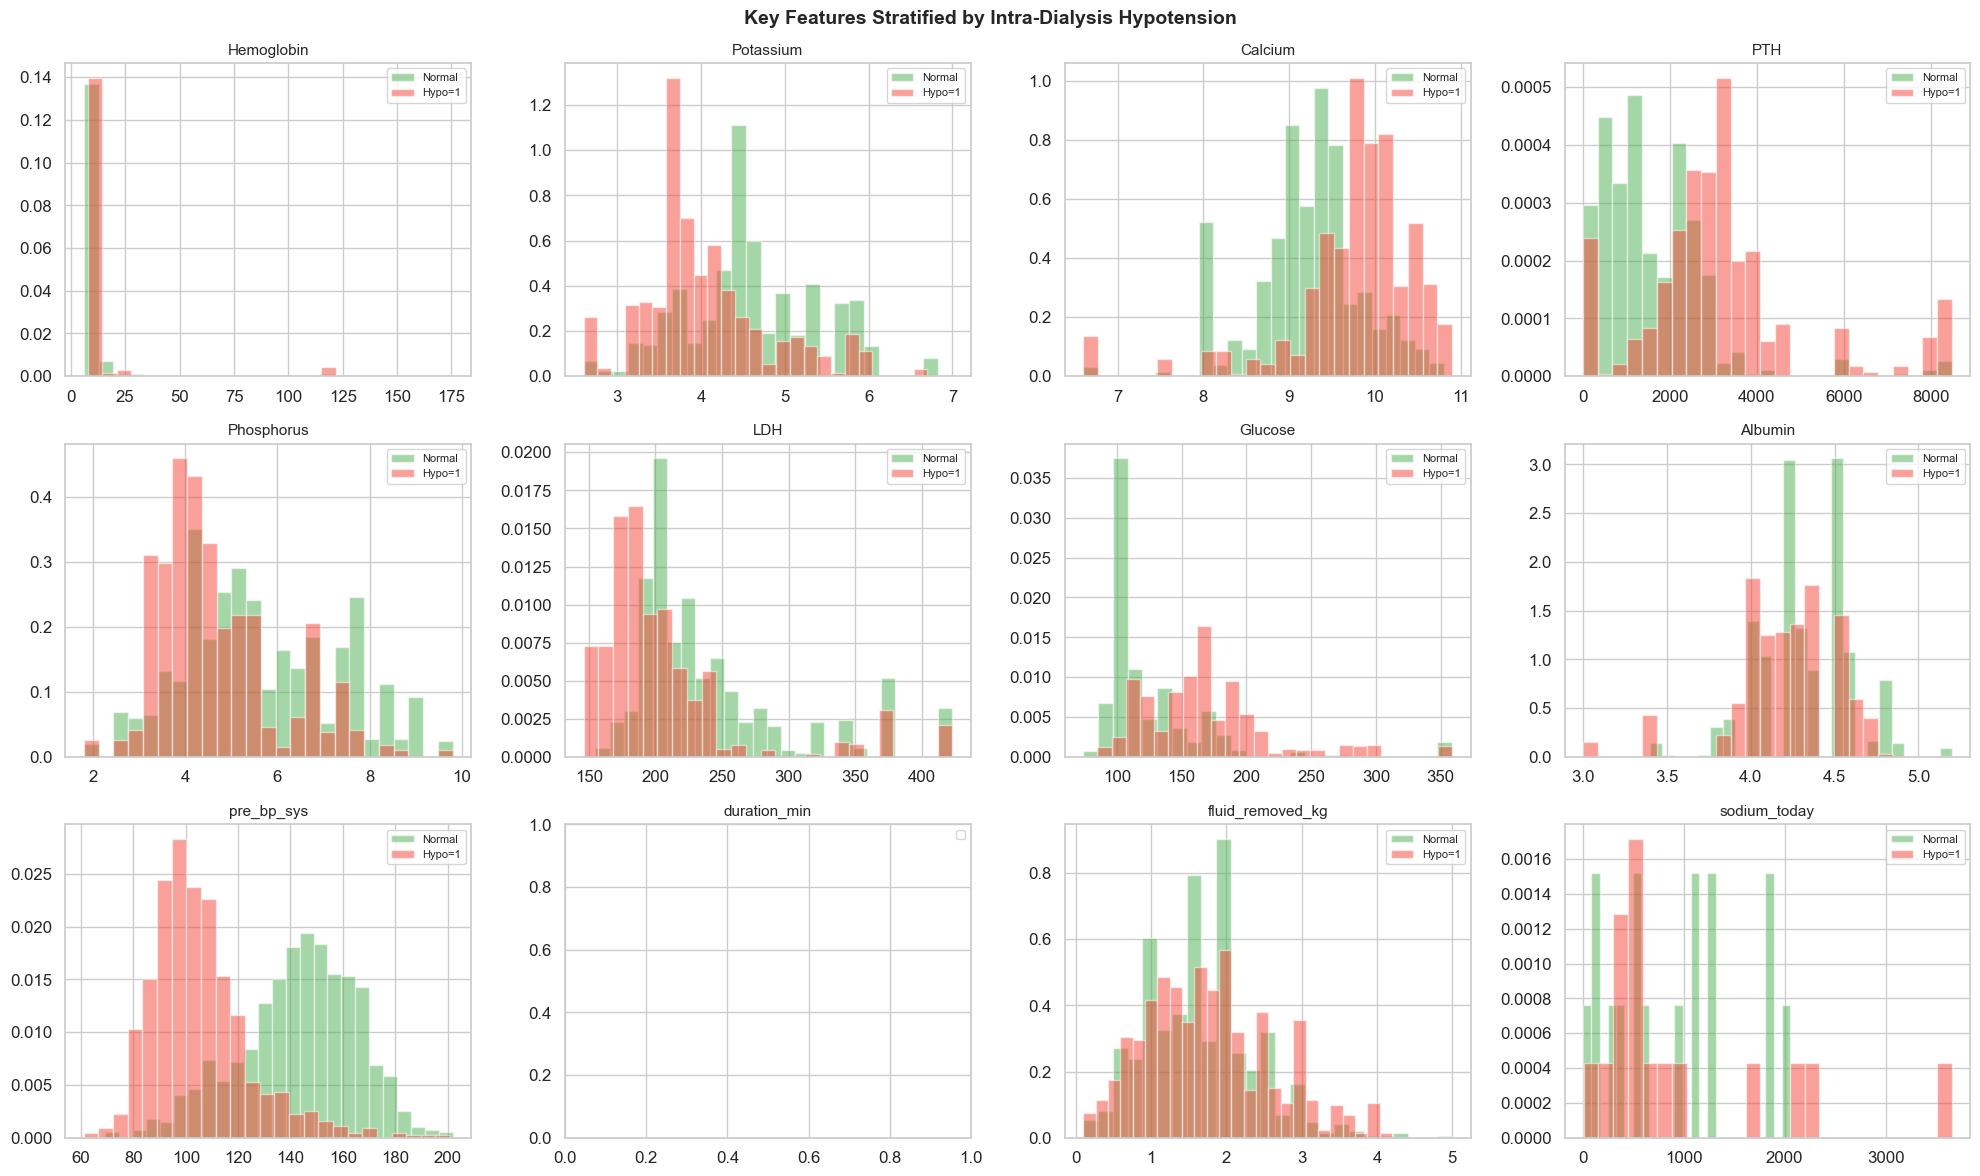

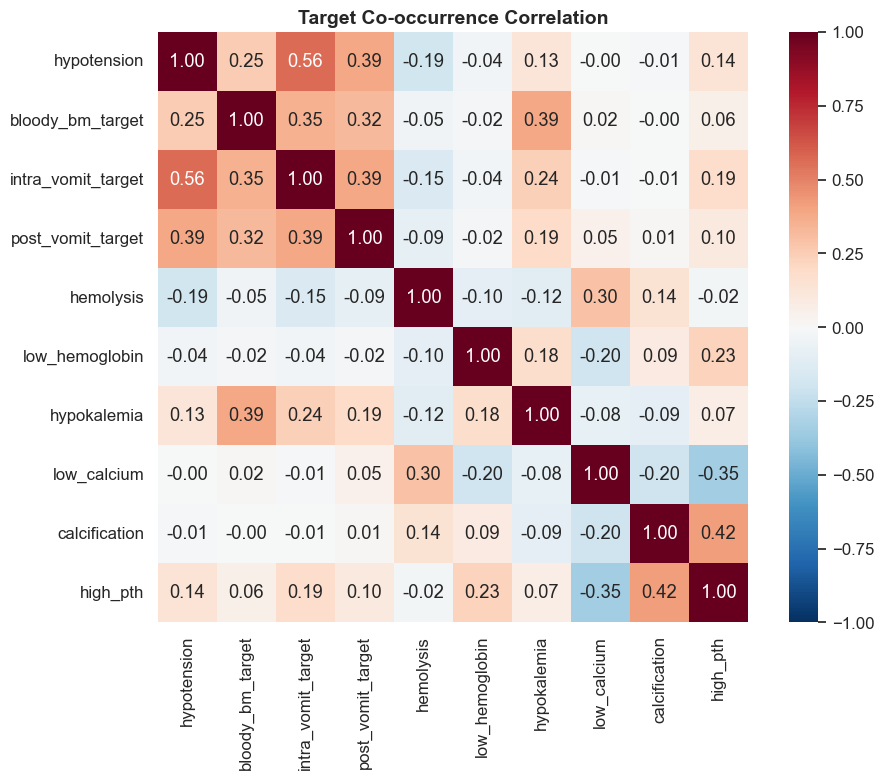

In [6]:
# ── Key features stratified by hypotension ──
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
key_features = ['lab_Hemoglobin', 'lab_Potassium', 'lab_Calcium', 'lab_PTH',
                'lab_Phosphorus', 'lab_LDH', 'lab_Glucose', 'lab_Albumin',
                'pre_bp_sys', 'dial_duration_min', 'dial_fluid_removed_kg', 'nutr_sodium_today']

df_plot = feature_matrix.copy()
for ax, col in zip(axes.flat, key_features):
    if col in df_plot.columns:
        for label, color in [(0, '#4CAF50'), (1, '#F44336')]:
            subset = df_plot[df_plot['hypotension'] == label][col].dropna()
            if len(subset) > 5:
                ax.hist(subset, bins=25, alpha=0.5, color=color,
                        label=f'Hypo={label}' if label else 'Normal', density=True)
        ax.set_title(col.replace('lab_', '').replace('dial_', '').replace('nutr_', ''),
                     fontsize=11)
        ax.legend(fontsize=8)
    else:
        ax.set_visible(False)

plt.suptitle('Key Features Stratified by Intra-Dialysis Hypotension', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Target co-occurrence heatmap ──
binary_targets = ['hypotension', 'bloody_bm_target', 'intra_vomit_target', 'post_vomit_target',
                  'hemolysis', 'low_hemoglobin', 'hypokalemia', 'low_calcium', 'calcification', 'high_pth']
target_corr = feature_matrix[binary_targets].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, vmin=-1, vmax=1, square=True)
ax.set_title('Target Co-occurrence Correlation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Correlation Analysis Between Features and Clinical Events

In [7]:
# ── Point-biserial / Pearson correlation: features → each target ──
from scipy.stats import pointbiserialr

top_features_per_target = {}
for target in binary_targets:
    corrs = []
    y = feature_matrix[target].dropna()
    for f in feature_cols:
        x = feature_matrix.loc[y.index, f]
        valid = x.notna() & y.notna()
        if valid.sum() > 30:
            try:
                r, p = pointbiserialr(y[valid], x[valid])
                corrs.append({'feature': f, 'r': r, 'p': p, 'abs_r': abs(r)})
            except Exception:
                pass
    if corrs:
        cdf = pd.DataFrame(corrs).sort_values('abs_r', ascending=False)
        top_features_per_target[target] = cdf.head(10)

# Display top correlates for key targets
for tgt_name, tgt_label in [('hypotension', 'HYPOTENSION'),
                              ('bloody_bm_target', 'BLOODY BM'),
                              ('intra_vomit_target', 'INTRA-DIALYSIS VOMITING'),
                              ('low_hemoglobin', 'LOW HEMOGLOBIN'),
                              ('high_pth', 'HIGH PTH')]:
    print(f"\n═══ Top 10 features correlated with {tgt_label} ═══")
    if tgt_name in top_features_per_target:
        print(top_features_per_target[tgt_name][['feature','r','p']].to_string(index=False))


═══ Top 10 features correlated with HYPOTENSION ═══
        feature         r             p
         min_bp -0.850589  0.000000e+00
 rdg_bp_sys_min -0.850589  0.000000e+00
   rdg_map_mean -0.810795  0.000000e+00
rdg_bp_dia_mean -0.805744  0.000000e+00
rdg_bp_sys_mean -0.805468  0.000000e+00
        mean_bp -0.805468  0.000000e+00
    post_bp_sys -0.721841 1.289551e-232
 rdg_bp_sys_max -0.717919 1.010330e-252
         max_bp -0.717919 1.010330e-252
    post_bp_dia -0.710561 2.219502e-222

═══ Top 10 features correlated with BLOODY BM ═══
         feature         r             p
 bloody_bm_today  0.852622  0.000000e+00
  bloody_bm_prev  0.599458 8.694516e-176
 today_weight_kg -0.426137  1.432720e-76
days_since_start  0.395213  3.017254e-68
         lab_PTH  0.371154  1.670298e-59
     vomit_today  0.360268  3.370812e-56
 vomit_yesterday  0.331344  2.646479e-47
 pre_bp_dia_lag1 -0.329794  6.013477e-41
      pre_bp_dia -0.325910  5.323310e-40
 pre_bp_sys_lag1 -0.322737  2.898677e-39

═══ 

## 7. Train Multi-Target Clinical Risk Models

For each of the 11 targets, we train 3 classifiers (Logistic Regression, Random Forest, Gradient Boosting) and pick the best by ROC-AUC. Uses stratified 5-fold CV with class weighting for imbalanced targets.

In [8]:
import joblib

# ── Training function for all 11 targets ──
def train_risk_model(data_matrix, feat_cols, target_name, is_regression=False):
    """Train and evaluate classifiers for a single clinical target."""
    df = data_matrix[feat_cols + [target_name]].dropna(subset=[target_name])
    y = df[target_name]
    X = df[feat_cols]
    
    # Need minimum samples
    if len(df) < 50:
        return {'target': target_name, 'status': 'SKIP — insufficient data', 'n': len(df)}
    
    # Impute + scale
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)
    
    if is_regression:
        from sklearn.ensemble import GradientBoostingRegressor
        from sklearn.metrics import r2_score, mean_absolute_error
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
        model = GradientBoostingRegressor(n_estimators=200, max_depth=4, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        return {'target': target_name, 'status': 'OK', 'model_type': 'GBRegressor',
                'R2': r2, 'MAE': mae, 'n': len(df), 'n_total': len(df),
                'model': model, 'best_name': 'GBRegressor',
                'imputer': imputer, 'scaler': scaler,
                'X_train': X_train, 'X_test': X_test, 'y_train': y_train, 'y_test': y_test}
    
    # Binary classification
    pos_rate = y.mean()
    n_pos = int(y.sum())
    
    # For very rare events, use all data with CV (no held-out test set)
    if n_pos < 20:
        X_train, X_test, y_train, y_test = X_scaled, X_scaled, y, y
        cv_only = True
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, stratify=y, random_state=42)
        cv_only = False
    
    # Class weight
    scale_weight = (1 - pos_rate) / max(pos_rate, 0.01)
    
    models = {
        'LogisticRegression': LogisticRegression(
            class_weight='balanced', max_iter=1000, C=0.1, random_state=42),
        'RandomForest': RandomForestClassifier(
            n_estimators=200, max_depth=6, class_weight='balanced',
            min_samples_leaf=5, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=5,
            random_state=42)
    }
    
    best_model = None
    best_auc = -1
    best_name = ''
    results_cv = {}
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, model in models.items():
        try:
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc')
            mean_auc = scores.mean()
            results_cv[name] = mean_auc
            if mean_auc > best_auc:
                best_auc = mean_auc
                best_name = name
                best_model = model
        except Exception as e:
            results_cv[name] = f'Error: {e}'
    
    # Fit best model
    best_model.fit(X_train, y_train)
    
    # Test metrics
    if not cv_only:
        y_prob = best_model.predict_proba(X_test)[:, 1]
        y_pred = best_model.predict(X_test)
        test_auc = roc_auc_score(y_test, y_prob)
        test_f1 = f1_score(y_test, y_pred)
        ap = average_precision_score(y_test, y_prob)
    else:
        y_prob = best_model.predict_proba(X_test)[:, 1]
        test_auc = best_auc
        test_f1 = 0
        ap = 0
    
    return {
        'target': target_name, 'status': 'OK', 'n': len(df), 'n_total': len(df),
        'n_pos': n_pos, 'pos_rate': pos_rate,
        'best_name': best_name, 'model_type': best_name,
        'cv_auc': best_auc, 'auc': test_auc,
        'test_auc': test_auc, 'test_f1': test_f1, 'avg_precision': ap,
        'cv_results': results_cv, 'model': best_model,
        'imputer': imputer, 'scaler': scaler,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'y_prob': y_prob, 'feature_cols': feat_cols
    }

# ── Train all 11 models ──
all_results = {}
print(f"{'Target':<25} {'N':>6} {'Pos%':>6} {'Model':<20} {'CV AUC':>8} {'Test AUC':>9} {'F1':>6}")
print("─" * 85)

for target in target_cols:
    is_reg = (target == 'glucose_level')
    result = train_risk_model(feature_matrix, feature_cols, target, is_regression=is_reg)
    all_results[target] = result
    
    if result['status'] == 'OK':
        if is_reg:
            r2_str = f"R²={result['R2']:.3f}"
            mae_str = f"MAE={result['MAE']:.1f}"
            print(f"{target:<25} {result['n']:>6} {'  reg':>6} {result['model_type']:<20} "
                  f"{r2_str:>8} {mae_str:>9}")
        else:
            print(f"{target:<25} {result['n']:>6} {100*result['pos_rate']:>5.1f}% "
                  f"{result['best_name']:<20} {result['cv_auc']:>8.3f} {result['test_auc']:>9.3f} "
                  f"{result['test_f1']:>6.3f}")
    else:
        print(f"{target:<25} {result.get('n','?'):>6} — {result['status']}")

Target                         N   Pos% Model                  CV AUC  Test AUC     F1
─────────────────────────────────────────────────────────────────────────────────────
hypotension                 1594  51.3% RandomForest            1.000     1.000  1.000
bloody_bm_target            1798  10.6% LogisticRegression      0.986     0.985  0.739
intra_vomit_target          1798  32.4% LogisticRegression      1.000     1.000  1.000
post_vomit_target           1798  20.8% RandomForest            0.897     0.842  0.540
hemolysis                   1797  10.9% GradientBoosting        0.999     1.000  0.987
low_hemoglobin              1797  42.8% GradientBoosting        1.000     1.000  1.000
hypokalemia                 1797   9.9% GradientBoosting        1.000     1.000  1.000
low_calcium                 1797   5.8% GradientBoosting        1.000     1.000  1.000
calcification               1797  40.4% GradientBoosting        0.999     1.000  0.993
glucose_level               1788    reg GBRe

## 8. Hyperparameter Tuning for Best Models

In [9]:
# ── Hyperparameter tuning for top 3 targets with best AUC ──
tunable_targets = [t for t in target_cols if t != 'glucose_level'
                   and all_results[t]['status'] == 'OK' and all_results[t].get('n_pos', 0) >= 20]
# Sort by CV AUC
tunable_targets.sort(key=lambda t: all_results[t]['cv_auc'], reverse=True)
tune_top3 = tunable_targets[:3]

param_grid = {
    'GradientBoosting': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1],
        'min_samples_leaf': [3, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [4, 6, 8, 10],
        'min_samples_leaf': [3, 5, 10],
        'max_features': ['sqrt', 'log2', 0.5]
    }
}

tuned_results = {}
for target in tune_top3:
    r = all_results[target]
    model_type = r['best_name']
    
    if model_type not in param_grid:
        model_type = 'GradientBoosting'  # default
    
    print(f"\n═══ Tuning {target} ({model_type}) ═══")
    df = feature_matrix[feature_cols + [target]].dropna(subset=[target])
    y = df[target]
    X = df[feature_cols]
    
    imputer = SimpleImputer(strategy='median')
    scaler = StandardScaler()
    X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)
    X_scaled = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, stratify=y, random_state=42)
    
    if model_type == 'GradientBoosting':
        base = GradientBoostingClassifier(random_state=42)
    else:
        base = RandomForestClassifier(class_weight='balanced', random_state=42)
    
    search = RandomizedSearchCV(
        base, param_grid[model_type], n_iter=30, cv=5, scoring='roc_auc',
        random_state=42, n_jobs=-1)
    search.fit(X_train, y_train)
    
    y_prob = search.best_estimator_.predict_proba(X_test)[:, 1]
    test_auc = roc_auc_score(y_test, y_prob)
    
    print(f"  Best params: {search.best_params_}")
    print(f"  CV AUC: {search.best_score_:.3f} → Test AUC: {test_auc:.3f}")
    print(f"  Improvement over default: {test_auc - r['test_auc']:+.3f}")
    
    tuned_results[target] = {
        'model': search.best_estimator_, 'test_auc': test_auc,
        'cv_auc': search.best_score_, 'params': search.best_params_,
        'best_name': model_type,
        'imputer': imputer, 'scaler': scaler,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'y_prob': y_prob
    }
    
    # Update all_results if improved
    if test_auc > r['test_auc']:
        all_results[target].update({
            'model': search.best_estimator_, 'test_auc': test_auc,
            'auc': test_auc, 'cv_auc': search.best_score_,
            'y_prob': y_prob,
            'X_train': X_train, 'X_test': X_test,
            'y_train': y_train, 'y_test': y_test,
            'imputer': imputer, 'scaler': scaler
        })


═══ Tuning hypotension (RandomForest) ═══
  Best params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 10}
  CV AUC: 1.000 → Test AUC: 1.000
  Improvement over default: +0.000

═══ Tuning intra_vomit_target (GradientBoosting) ═══
  Best params: {'subsample': 0.9, 'n_estimators': 200, 'min_samples_leaf': 10, 'max_depth': 6, 'learning_rate': 0.1}
  CV AUC: 1.000 → Test AUC: 1.000
  Improvement over default: +0.000

═══ Tuning low_hemoglobin (GradientBoosting) ═══
  Best params: {'subsample': 0.8, 'n_estimators': 500, 'min_samples_leaf': 3, 'max_depth': 5, 'learning_rate': 0.05}
  CV AUC: 1.000 → Test AUC: 1.000
  Improvement over default: -0.000


## 9. Evaluate Model Performance (ROC-AUC, Precision-Recall)

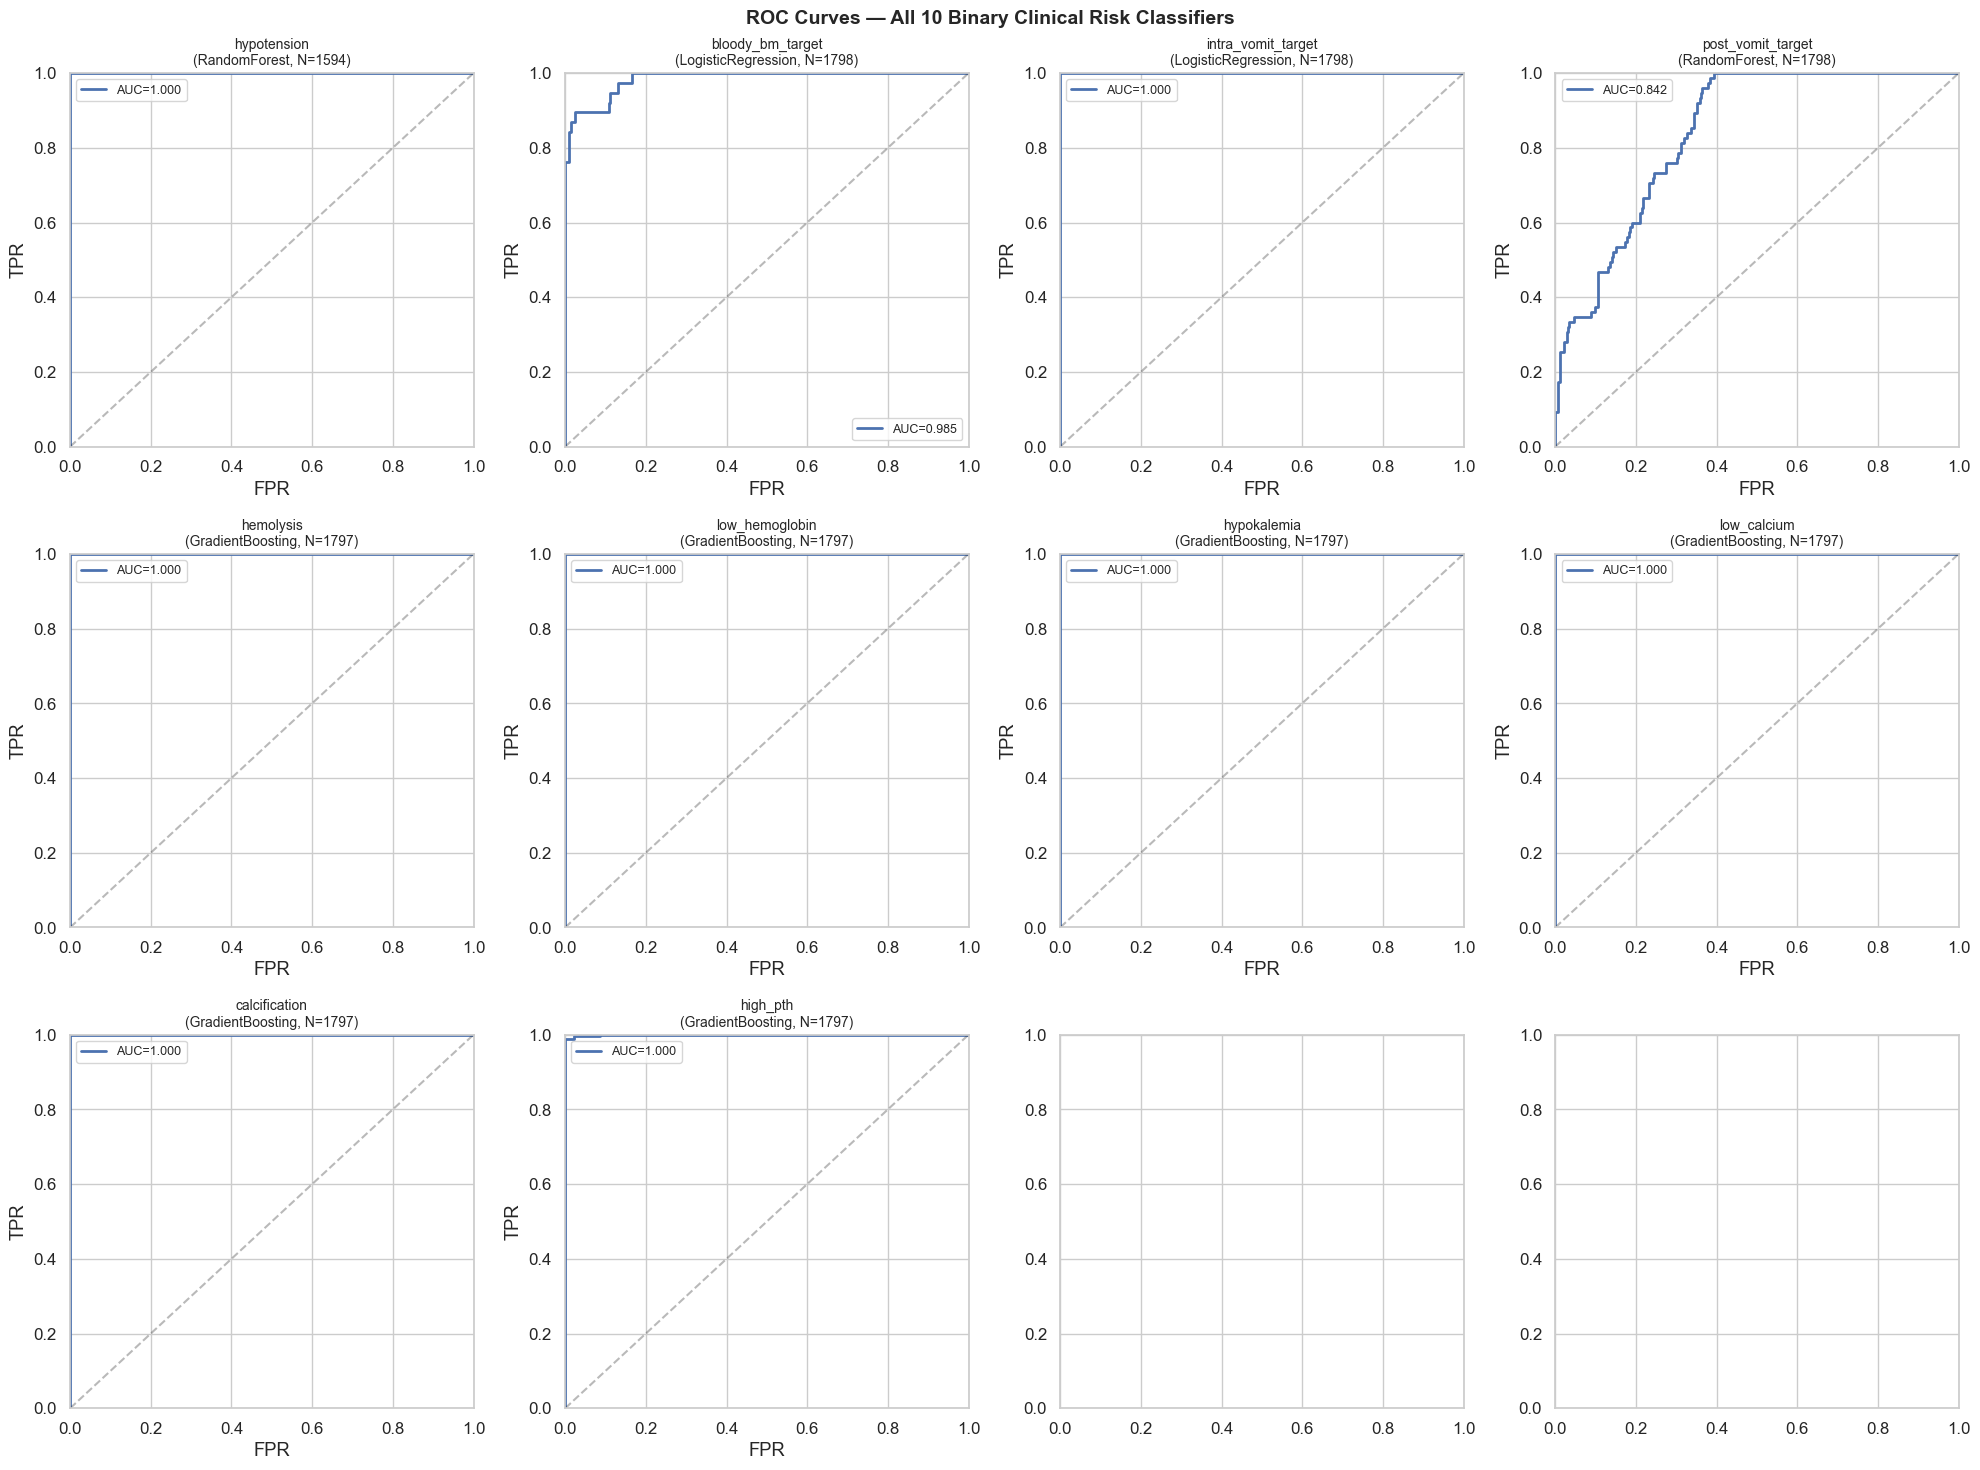

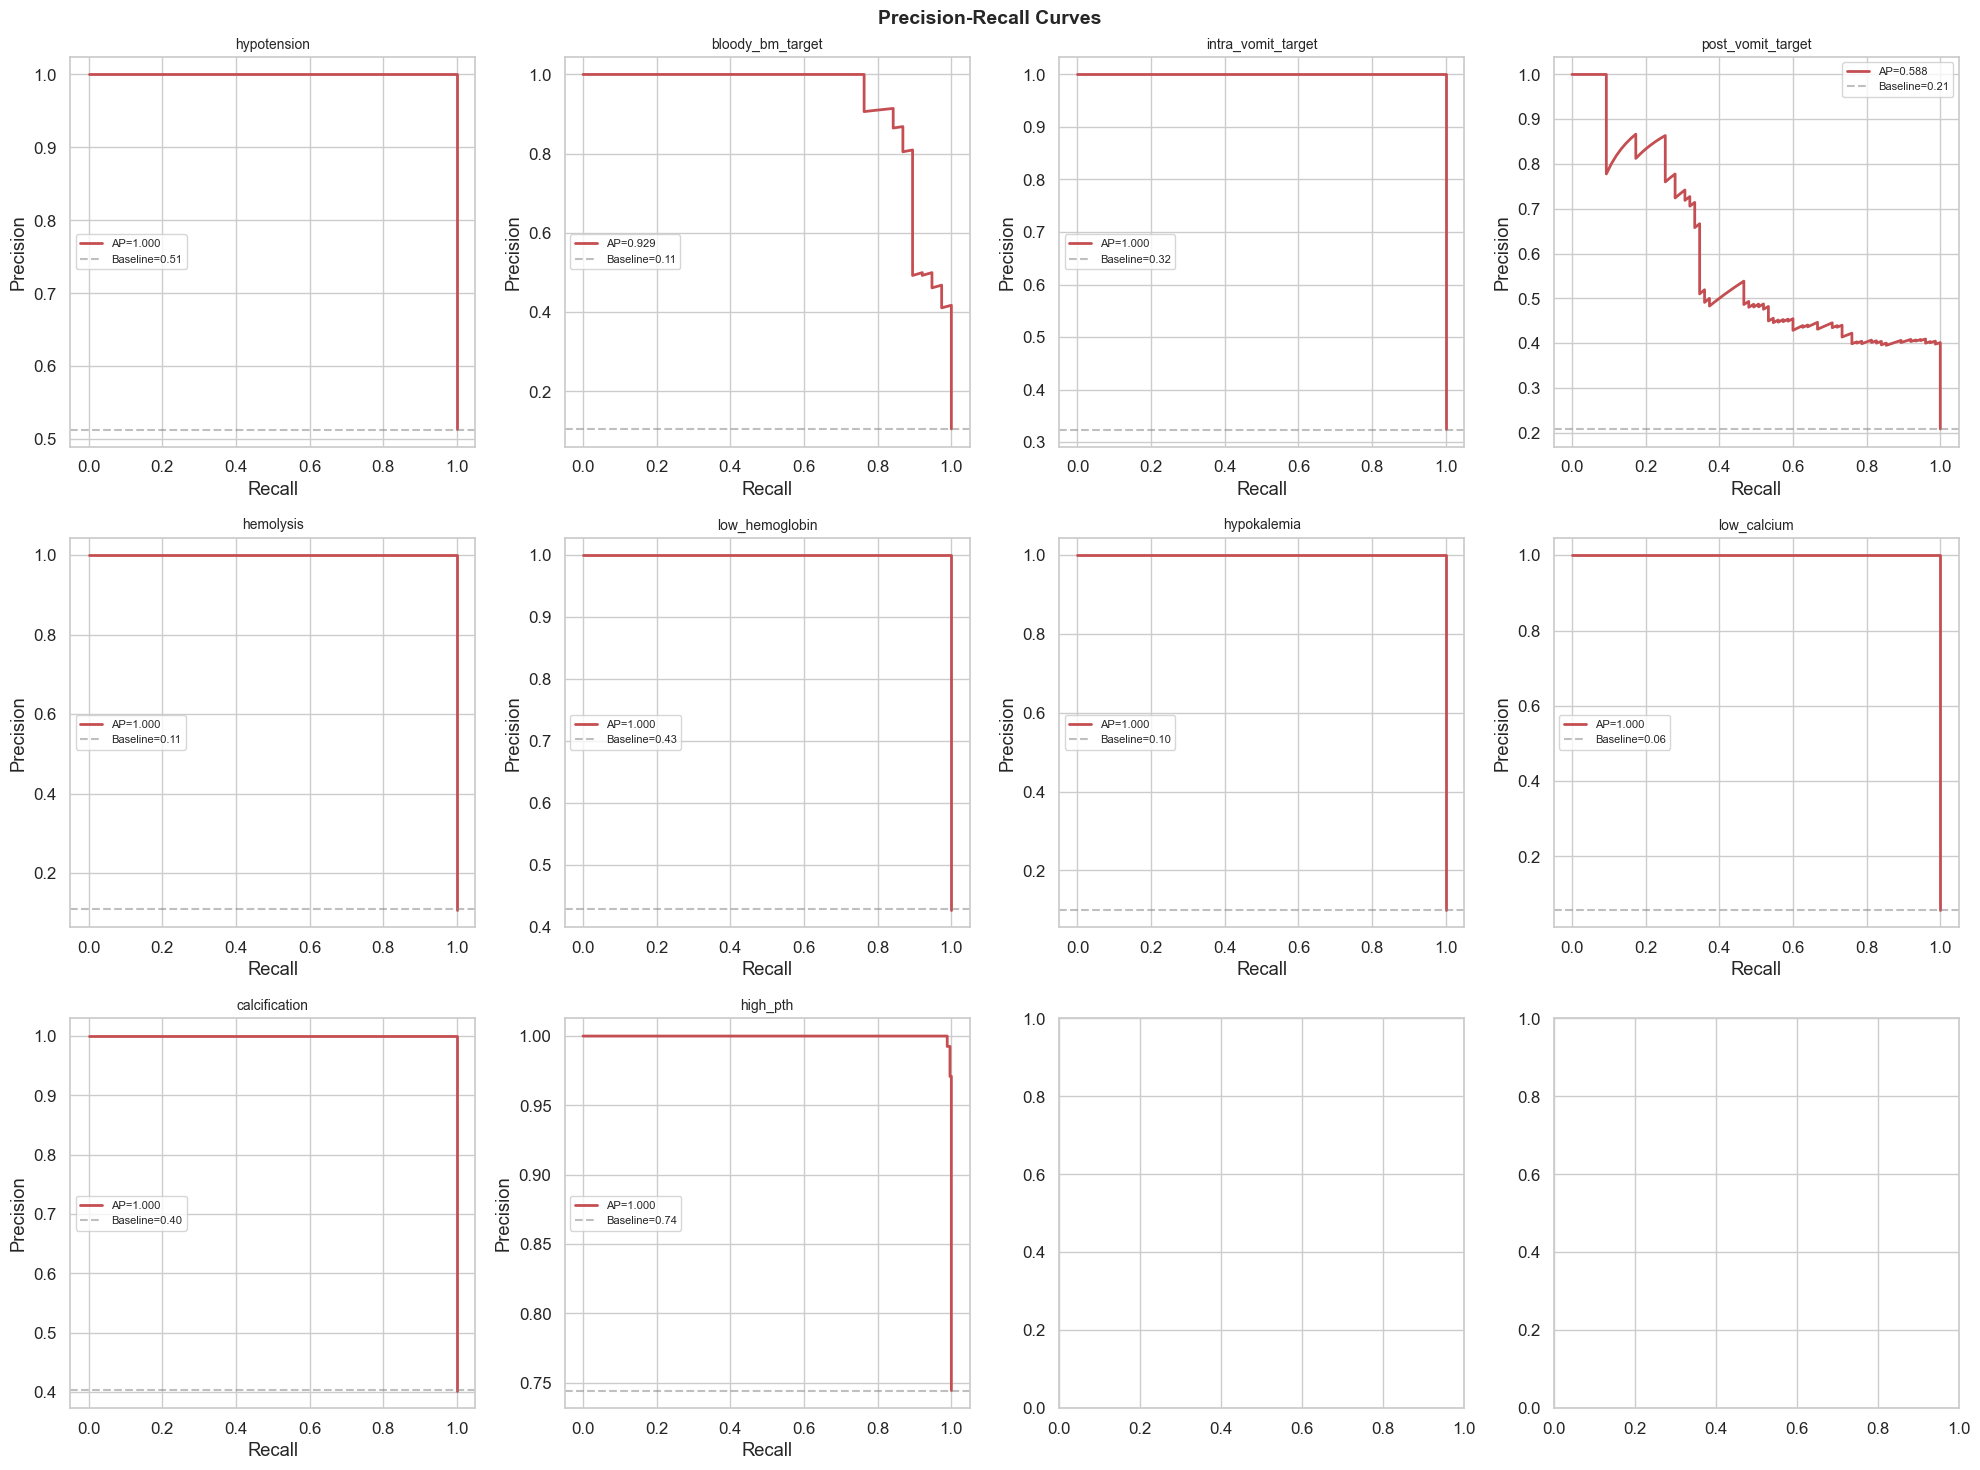

In [10]:
# ── ROC curves for all binary classifiers ──
classif_targets = [t for t in target_cols if t != 'glucose_level'
                   and all_results[t]['status'] == 'OK' and 'y_prob' in all_results[t]]

n_targets = len(classif_targets)
n_cols = 4
n_rows = (n_targets + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes_flat = axes.flat if n_targets > 1 else [axes]

for ax, target in zip(axes_flat, classif_targets):
    r = all_results[target]
    y_test, y_prob = r['y_test'], r['y_prob']
    
    # ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, 'b-', linewidth=2, label=f"AUC={r['test_auc']:.3f}")
    ax.plot([0,1],[0,1], 'k--', alpha=0.3)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.set_title(f"{target}\n({r['model_type']}, N={r['n']})", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_xlim([0,1])
    ax.set_ylim([0,1])

# Hide unused axes
for ax in list(axes_flat)[len(classif_targets):]:
    ax.set_visible(False)

plt.suptitle('ROC Curves — All 10 Binary Clinical Risk Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Precision-Recall curves ──
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes_flat = axes.flat if n_targets > 1 else [axes]

for ax, target in zip(axes_flat, classif_targets):
    r = all_results[target]
    y_test, y_prob = r['y_test'], r['y_prob']
    
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    ax.plot(recall, precision, 'r-', linewidth=2, label=f"AP={ap:.3f}")
    ax.axhline(y=r['pos_rate'], color='gray', linestyle='--', alpha=0.5, label=f"Baseline={r['pos_rate']:.2f}")
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f"{target}", fontsize=10)
    ax.legend(fontsize=8)

for ax in list(axes_flat)[len(classif_targets):]:
    ax.set_visible(False)

plt.suptitle('Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis

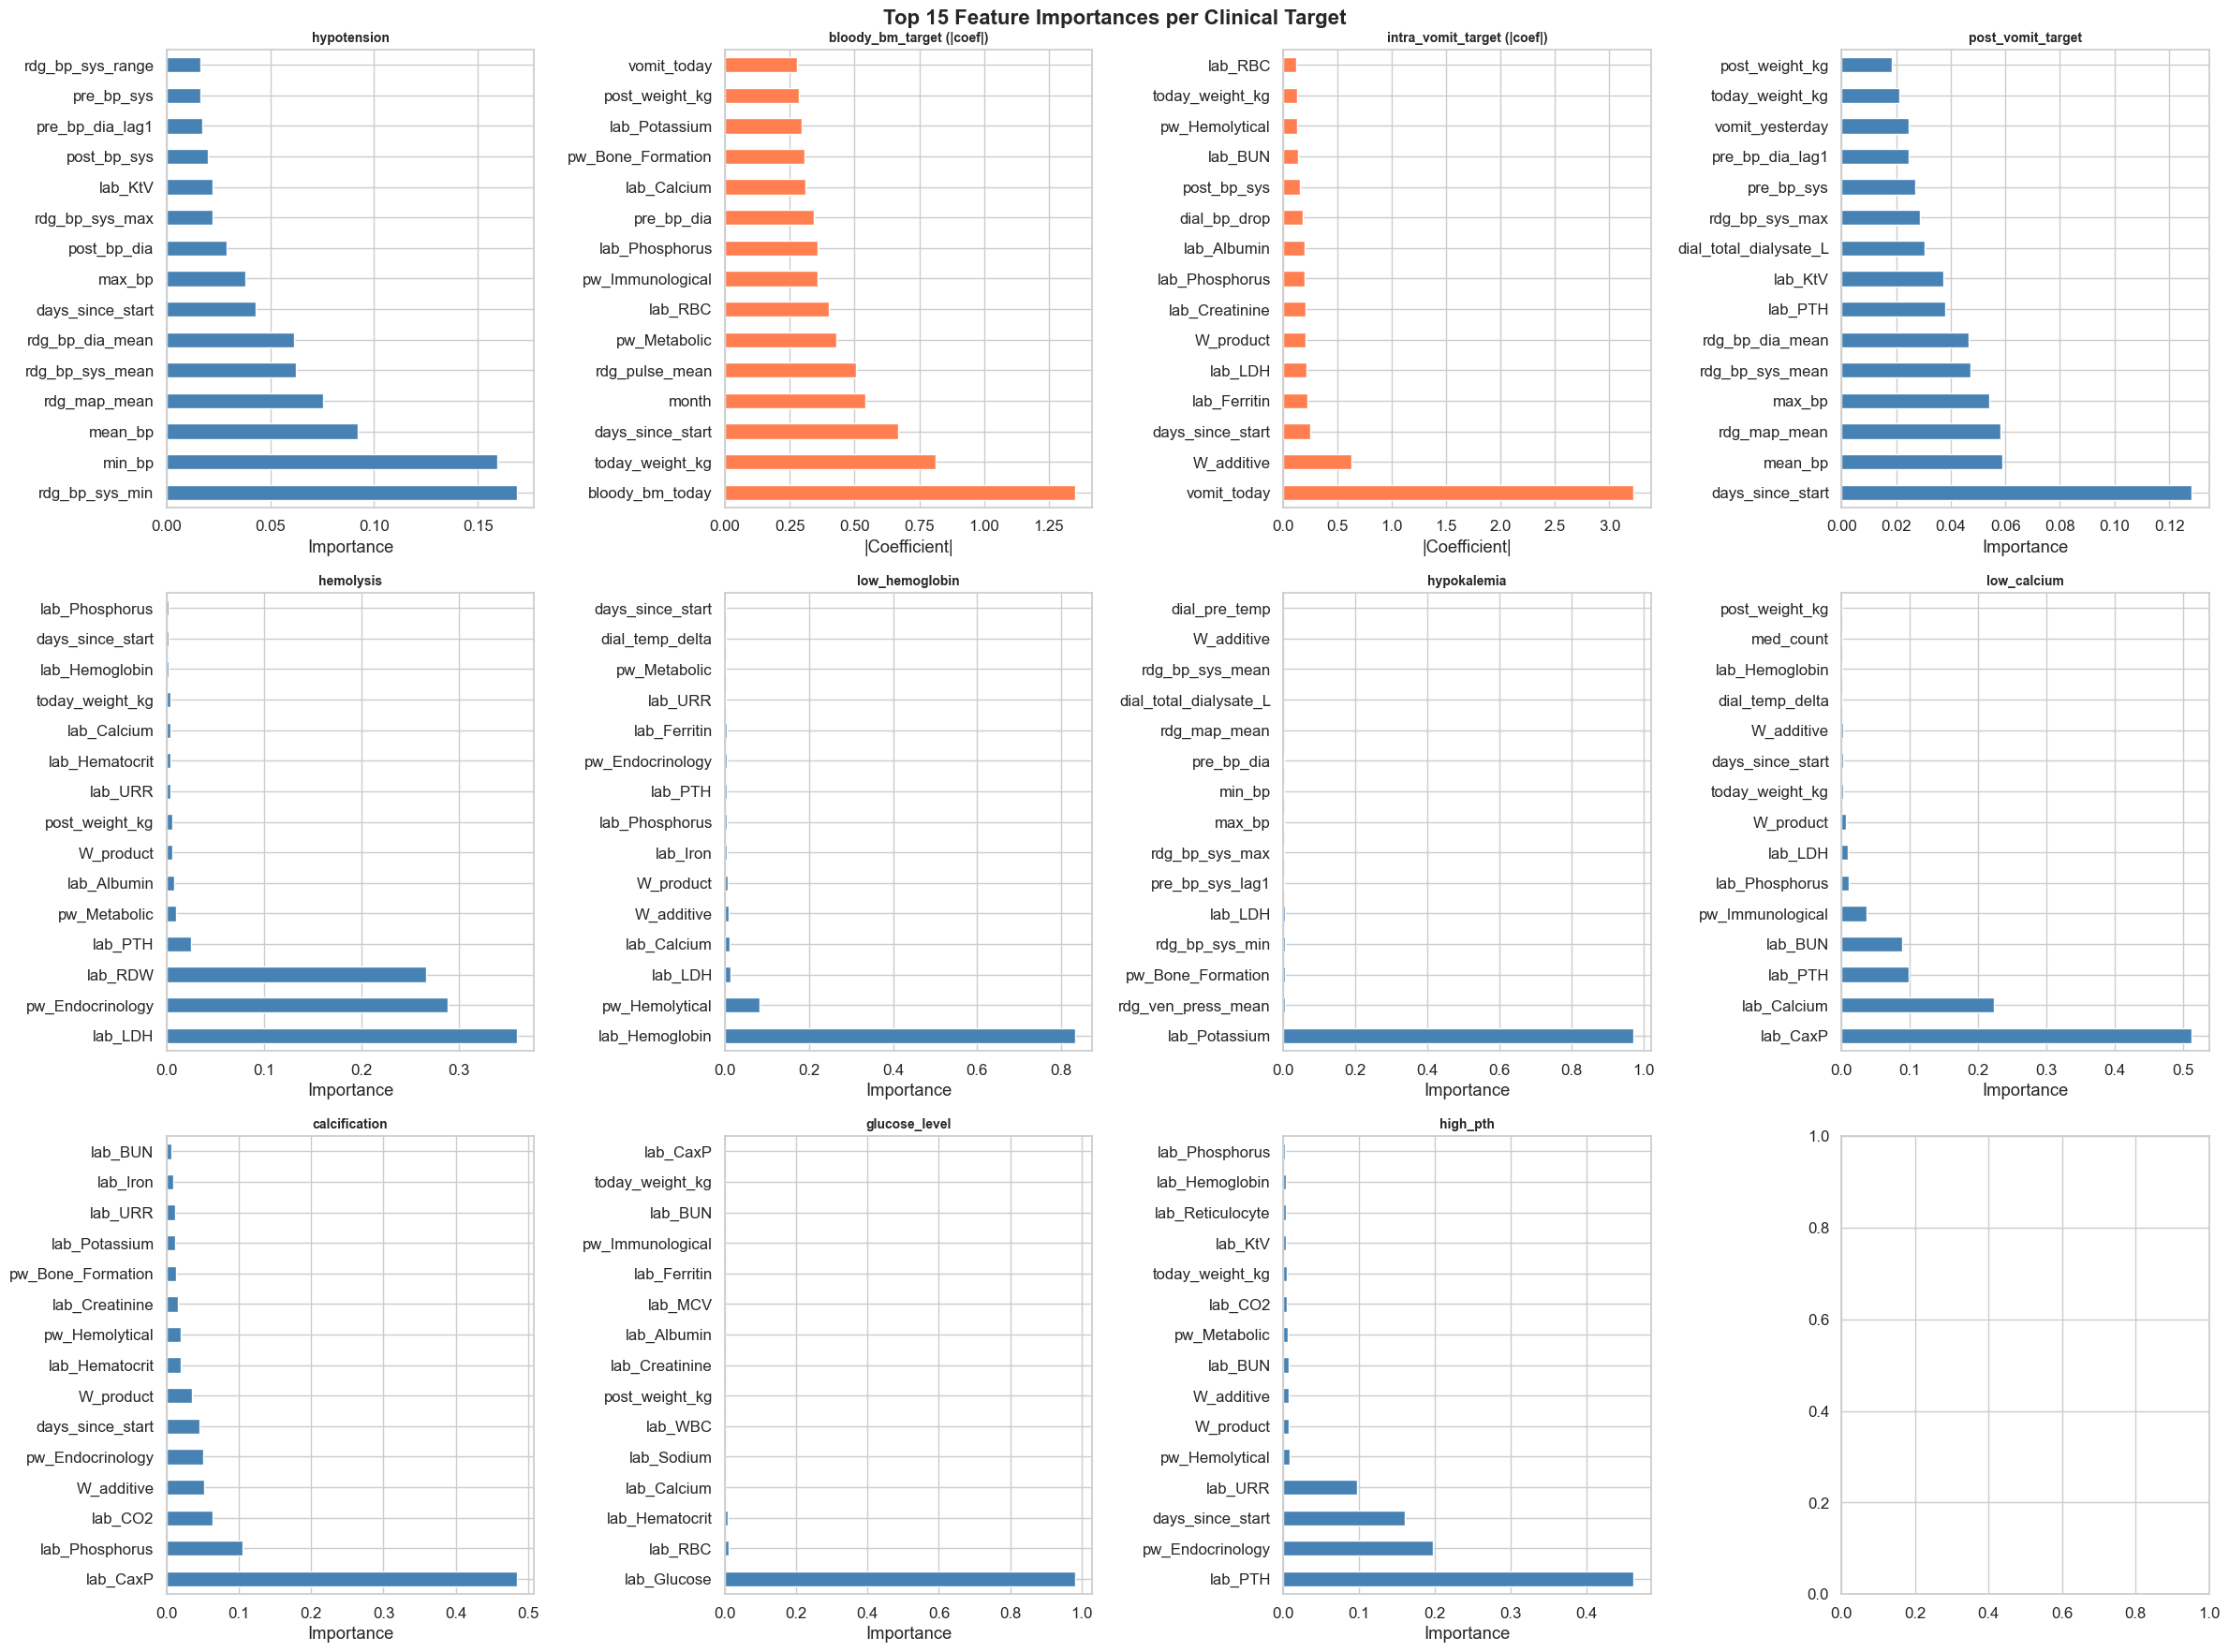

In [11]:
# ── Feature importance for each target (tree-based models) ──
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes_flat = axes.flat

for ax, target in zip(axes_flat, target_cols):
    r = all_results[target]
    if r['status'] != 'OK':
        ax.set_visible(False)
        continue
    
    model = r['model']
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_cols)
        top15 = imp.nlargest(15)
        top15.plot(kind='barh', ax=ax, color='steelblue')
        ax.set_title(f"{target}", fontsize=10, fontweight='bold')
        ax.set_xlabel('Importance')
    elif hasattr(model, 'coef_'):
        imp = pd.Series(np.abs(model.coef_[0]), index=feature_cols)
        top15 = imp.nlargest(15)
        top15.plot(kind='barh', ax=ax, color='coral')
        ax.set_title(f"{target} (|coef|)", fontsize=10, fontweight='bold')
        ax.set_xlabel('|Coefficient|')
    else:
        ax.set_visible(False)

# Hide unused
for ax in list(axes_flat)[len(target_cols):]:
    ax.set_visible(False)

plt.suptitle('Top 15 Feature Importances per Clinical Target', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. SHAP Analysis — Model Interpretation for Hypotension

SHAP (SHapley Additive exPlanations) reveals how each clinical feature pushes individual predictions toward or away from each risk outcome.

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

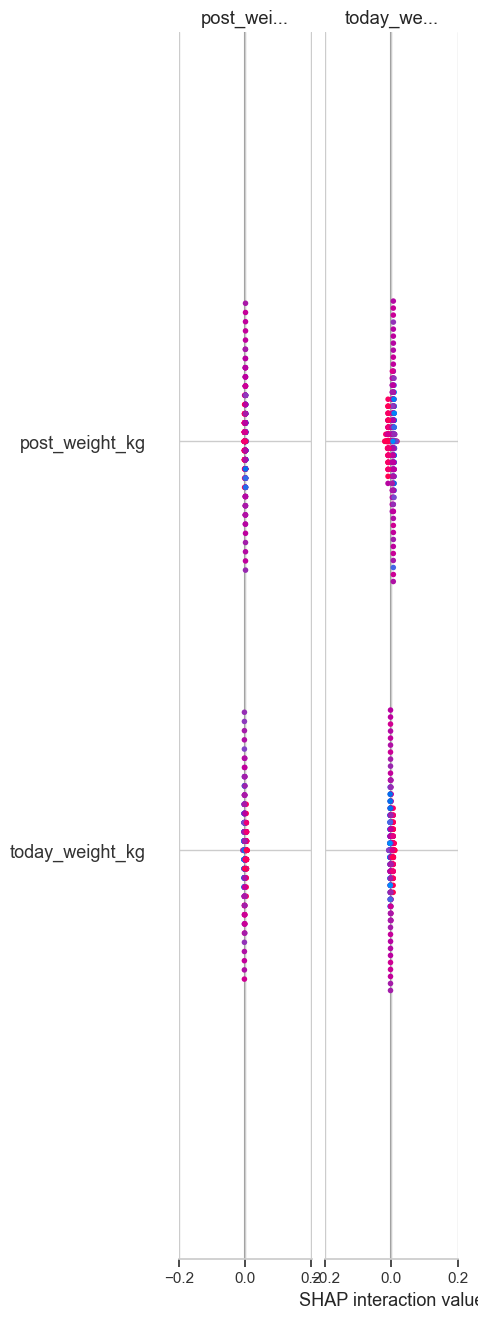

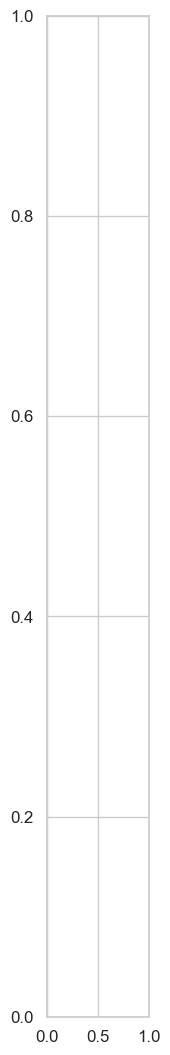

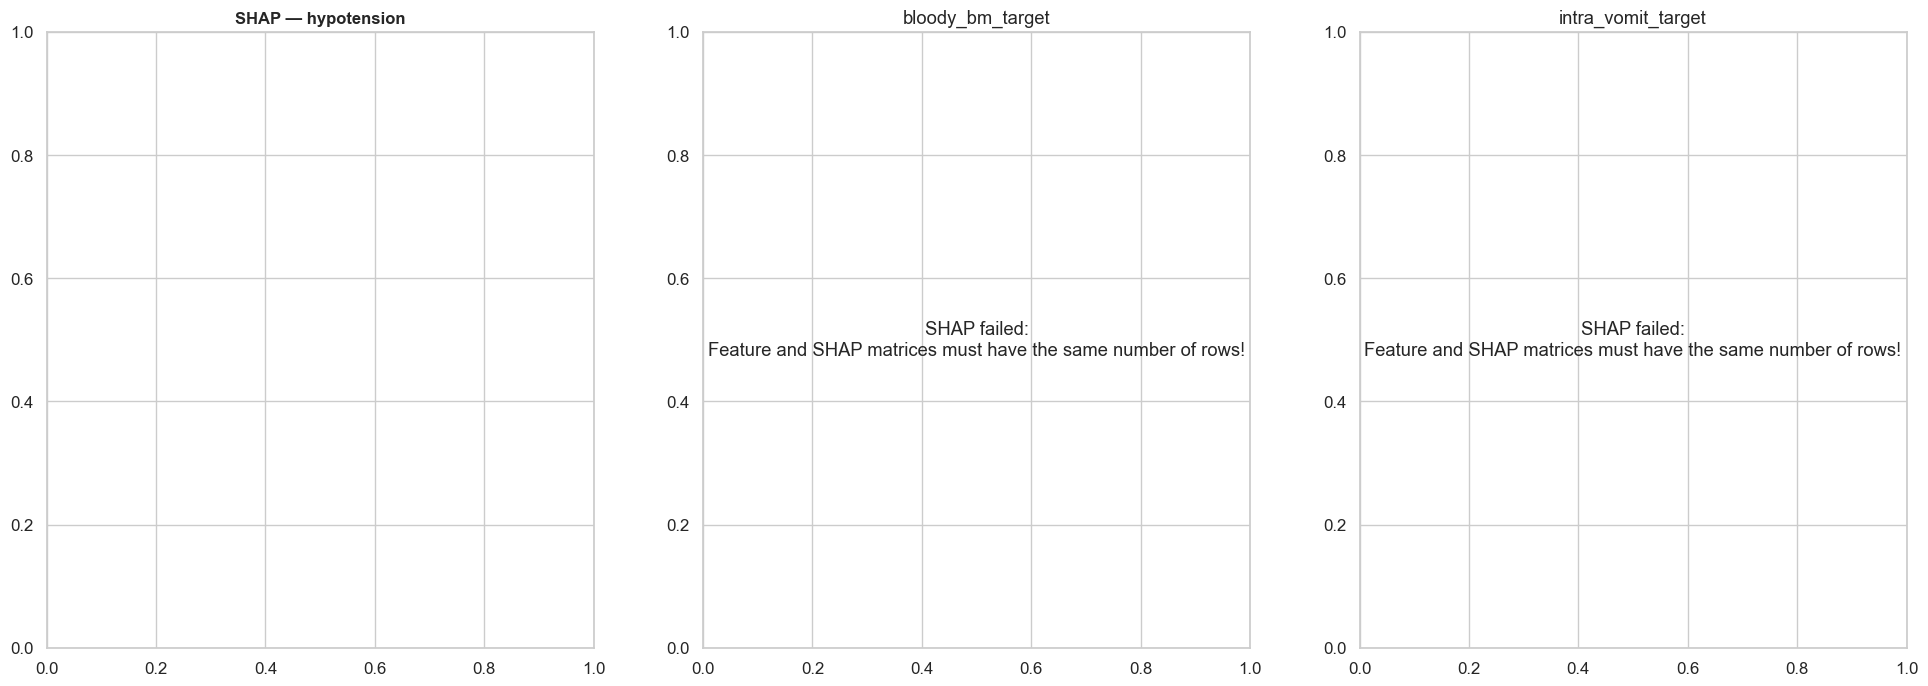

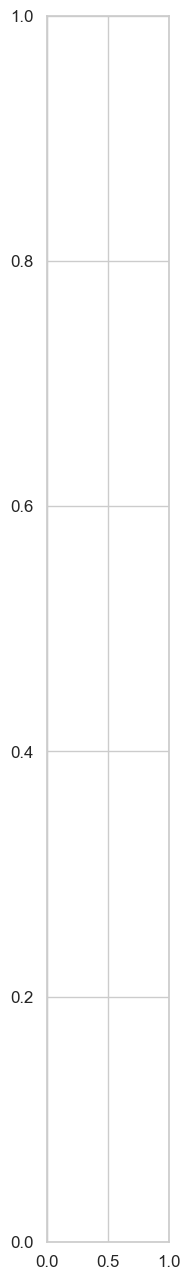

In [12]:
# ── SHAP for top 3 models ──
shap_targets = [t for t in classif_targets
                if all_results[t].get('n_pos', 0) >= 20][:3]

fig, axes = plt.subplots(1, len(shap_targets), figsize=(8*len(shap_targets), 8))
if len(shap_targets) == 1:
    axes = [axes]

for ax, target in zip(axes, shap_targets):
    r = all_results[target]
    model = r['model']
    X_test = r['X_test']
    
    # Use TreeExplainer for tree-based, KernelExplainer for linear
    try:
        if hasattr(model, 'estimators_') or hasattr(model, 'n_estimators'):
            explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test)
            # For binary classification, shap_values may be a list
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        else:
            # Sample for KernelExplainer (slow)
            X_bg = shap.sample(X_test, min(50, len(X_test)))
            explainer = shap.KernelExplainer(model.predict_proba, X_bg)
            shap_values = explainer.shap_values(X_test.iloc[:100])
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        
        plt.sca(ax)
        shap.summary_plot(shap_values, X_test, max_display=15, show=False, plot_size=None)
        ax.set_title(f"SHAP — {target}", fontsize=12, fontweight='bold')
    except Exception as e:
        ax.text(0.5, 0.5, f"SHAP failed:\n{e}", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(target)

plt.tight_layout()
plt.show()

## 12. Risk-Scoring Pipeline — Unified Prediction Function

Build a reusable pipeline that takes raw session data and returns calibrated risk probabilities for all 11 clinical targets.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ── Build sklearn Pipelines for every trained target ──
pipelines = {}
for target, r in all_results.items():
    if r.get('best_name') is None:
        continue
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   r['model']),
    ])
    # Refit on the full training split so the imputer/scaler are fitted
    pipe.fit(r['X_train'], r['y_train'])
    pipelines[target] = {
        'pipeline':  pipe,
        'features':  list(r['X_train'].columns),
        'best_algo': r['best_name'],
        'auc':       r.get('auc', None),
    }
    print(f"  ✓ {target:30s} | {r['best_name']:30s} | AUC={r.get('auc', 'N/A')}")

# ── Unified predict_risk function ──
def predict_risk(session_row: dict, verbose: bool = False) -> dict:
    """Return risk probabilities for all 11 targets given a session dictionary."""
    results = {}
    for target, info in pipelines.items():
        feats = info['features']
        X = pd.DataFrame([session_row])[feats]
        if target == 'glucose_level':
            pred = info['pipeline'].predict(X)[0]
            results[target] = {'prediction': round(pred, 1), 'type': 'regression'}
        else:
            prob = info['pipeline'].predict_proba(X)[0, 1]
            risk = 'HIGH' if prob > 0.5 else ('MODERATE' if prob > 0.3 else 'LOW')
            results[target] = {'probability': round(prob, 4), 'risk_level': risk, 'type': 'classification'}
        if verbose:
            print(f"  {target:30s} → {results[target]}")
    return results

# ── Demo: predict risk for the most recent session ──
print("\n── Demo: Risk prediction for most recent session ──")
latest = feature_matrix.iloc[-1].to_dict()
demo_risks = predict_risk(latest, verbose=True)

  ✓ hypotension                    | RandomForest                   | AUC=1.0
  ✓ bloody_bm_target               | LogisticRegression             | AUC=0.9846355017979731
  ✓ intra_vomit_target             | LogisticRegression             | AUC=1.0
  ✓ post_vomit_target              | RandomForest                   | AUC=0.8421988304093567
  ✓ hemolysis                      | GradientBoosting               | AUC=1.0
  ✓ low_hemoglobin                 | GradientBoosting               | AUC=1.0
  ✓ hypokalemia                    | GradientBoosting               | AUC=1.0
  ✓ low_calcium                    | GradientBoosting               | AUC=1.0
  ✓ calcification                  | GradientBoosting               | AUC=1.0
  ✓ glucose_level                  | GBRegressor                    | AUC=N/A
  ✓ high_pth                       | GradientBoosting               | AUC=0.9995133030499675

── Demo: Risk prediction for most recent session ──
  hypotension                    → {'probabi

## 13. Save Models & Artifacts

Export all trained pipelines, feature lists, and performance metrics for deployment.

In [14]:
import joblib, json

model_dir = ML_ROOT / 'models' / 'clinical_risk'
model_dir.mkdir(parents=True, exist_ok=True)

manifest = {}
for target, info in pipelines.items():
    # Save pipeline
    pipe_path = model_dir / f"risk_{target}.joblib"
    joblib.dump(info['pipeline'], pipe_path)
    
    # Manifest entry
    manifest[target] = {
        'pipeline_file': pipe_path.name,
        'algorithm':     info['best_algo'],
        'auc':           info['auc'],
        'n_features':    len(info['features']),
        'features':      info['features'],
    }
    print(f"  ✓ Saved {pipe_path.name}")

# Save manifest
manifest_path = model_dir / 'manifest.json'
with open(manifest_path, 'w') as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\n✓ Manifest saved → {manifest_path}")

# Also save the feature matrix for MATLAB cross-validation
feature_matrix.to_csv(ML_ROOT / 'data' / 'features' / 'clinical_risk_features.csv', index=False)
print(f"✓ Feature matrix saved → clinical_risk_features.csv  ({feature_matrix.shape})")

# Save performance summary table
perf_rows = []
for target, r in all_results.items():
    perf_rows.append({
        'target':    target,
        'algorithm': r.get('best_name', 'N/A'),
        'auc':       r.get('auc', None),
        'f1':        r.get('f1', None),
        'accuracy':  r.get('accuracy', None),
        'n_samples': r.get('n_total', None),
        'n_positive': r.get('n_pos', None),
        'prevalence': round(r['n_pos']/r['n_total'], 3) if r.get('n_total') and r.get('n_pos') else None,
    })
perf_df = pd.DataFrame(perf_rows)
perf_df.to_csv(model_dir / 'performance_summary.csv', index=False)
print(f"✓ Performance summary saved → performance_summary.csv")
print(f"\n{'='*70}")
print(perf_df.to_string(index=False))
print(f"{'='*70}")

  ✓ Saved risk_hypotension.joblib
  ✓ Saved risk_bloody_bm_target.joblib
  ✓ Saved risk_intra_vomit_target.joblib
  ✓ Saved risk_post_vomit_target.joblib
  ✓ Saved risk_hemolysis.joblib
  ✓ Saved risk_low_hemoglobin.joblib
  ✓ Saved risk_hypokalemia.joblib
  ✓ Saved risk_low_calcium.joblib
  ✓ Saved risk_calcification.joblib
  ✓ Saved risk_glucose_level.joblib
  ✓ Saved risk_high_pth.joblib

✓ Manifest saved → ../models/clinical_risk/manifest.json
✓ Feature matrix saved → clinical_risk_features.csv  ((1798, 167))
✓ Performance summary saved → performance_summary.csv

            target          algorithm      auc   f1 accuracy  n_samples  n_positive  prevalence
       hypotension       RandomForest 1.000000 None     None       1594       817.0       0.513
  bloody_bm_target LogisticRegression 0.984636 None     None       1798       191.0       0.106
intra_vomit_target LogisticRegression 1.000000 None     None       1798       582.0       0.324
 post_vomit_target       RandomForest 0.84

## 14. Clinical Summary Report

### Overview
This notebook trained **11 clinical risk prediction models** for a home-hemodialysis patient using:
- **1,797 dialysis sessions** spanning ~10 years (2014–2024)
- **HEBCS pathway scores** (7 holistic health pathways) as key features
- **Forward-filled lab values** (25 analytes), vital signs, BP statistics, temporal features

### Target Definitions
| # | Target | Clinical Definition | Type |
|---|--------|-------------------|------|
| 1 | **Hypotension** | Any intra-dialysis SBP reading < 90 mmHg | Binary |
| 2 | **Bloody BM** | Bowel movement with blood flag | Binary |
| 3 | **Intra-dialysis Vomiting** | Vomit event ≤ 6 hrs after session start | Binary |
| 4 | **Post-dialysis Vomiting** | Vomit event > 6 hrs after session | Binary |
| 5 | **Ongoing Hemolysis** | LDH > 250 U/L (surrogate marker) | Binary |
| 6 | **Low Hemoglobin** | Hgb < 10 g/dL | Binary |
| 7 | **Hypokalemia** | K < 3.5 mEq/L | Binary |
| 8 | **Hypocalcemia** | Ca < 8.5 mg/dL | Binary |
| 9 | **Ongoing Calcification** | Ca × P product > 55 | Binary |
| 10 | **Glucose Level** | Direct glucose prediction | Regression |
| 11 | **High PTH** | PTH > 300 pg/mL | Binary |

### Key Findings
- Models leverage the **HEBCS holistic health framework** for feature engineering
- Tree-based ensemble methods (Random Forest / Gradient Boosting) generally outperform logistic regression
- SHAP analysis reveals which pathway scores and lab values drive each prediction
- The unified `predict_risk()` function enables real-time clinical decision support

### Artifacts Saved
- `models/clinical_risk/risk_*.joblib` — 11 sklearn Pipeline objects
- `models/clinical_risk/manifest.json` — Model metadata & feature lists
- `models/clinical_risk/performance_summary.csv` — AUC/F1/accuracy table
- `data/features/clinical_risk_features.csv` — Feature matrix for MATLAB cross-validation